In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
httpx2 2.4.0 requires idna>=3.18, but you have idna 3.7 which i

In [2]:
# Dataset 1: TIRED DETECTION
from roboflow import Roboflow
from google.colab import userdata

rf = Roboflow(api_key=userdata.get('SmokeFD'))
project1 = rf.workspace("smoke-tcfs5").project("tired-detect")
version1 = project1.version(3)
dataset1 = version1.download("yolov11", location="dataset1")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset1 in yolov11:: 100%|██████████| 6415/6415 [00:00<00:00, 6938.27it/s]


In [3]:
# Dataset 2: FATIGUE DETECTION
from roboflow import Roboflow
from google.colab import userdata

rf = Roboflow(api_key=userdata.get('AthenaFD'))
project2 = rf.workspace("athena-ba1wv").project("fatigue-detection-loo95")
version2 = project2.version(1)
dataset2 = version2.download("yolov11", location="dataset2")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset2 in yolov11:: 100%|██████████| 5840/5840 [00:00<00:00, 7853.59it/s]


In [7]:
import yaml

def load_classes(path):
    with open(path) as f:
        data = yaml.safe_load(f)
    return data['names']

classes1 = load_classes("dataset1/data.yaml")
classes2 = load_classes("dataset2/data.yaml")

print("Dataset 1 classes:", classes1)
print("Dataset 2 classes:", classes2)

if classes1 == classes2:
    print("✅ SUDAH SINKRON — urutan & nama kelas sama persis")
else:
    print("❌ BELUM SINKRON")
    set1, set2 = set(classes1), set(classes2)
    if set1 != set2:
        print("  Nama kelas beda:", set1.symmetric_difference(set2))
    else:
        print("  Nama sama tapi URUTAN beda — ini bahaya karena ID akan salah mapping saat training!")
        print("  Urutan 1:", classes1)
        print("  Urutan 2:", classes2)

Dataset 1 classes: ['closed_eye', 'closed_mouth', 'open_eye', 'open_mouth']
Dataset 2 classes: ['closed_eye', 'closed_mouth', 'open_eye', 'open_mouth']
✅ SUDAH SINKRON — urutan & nama kelas sama persis


In [8]:
import os, shutil, random
from pathlib import Path
from collections import defaultdict

random.seed(42)

def get_all_files(base="merged"):
    files = []
    for split in ["train", "valid", "test"]:
        img_dir = Path(f"{base}/{split}/images")
        for img in img_dir.glob("*"):
            lbl = Path(f"{base}/{split}/labels") / (img.stem + ".txt")
            if lbl.exists():
                files.append((img, lbl))
    return files

all_files = get_all_files()
random.shuffle(all_files)

n = len(all_files)
train_end = int(n * 0.7)
valid_end = int(n * 0.9)

splits = {
    "train": all_files[:train_end],
    "valid": all_files[train_end:valid_end],
    "test": all_files[valid_end:]
}

for split, files in splits.items():
    img_out = Path(f"final/{split}/images")
    lbl_out = Path(f"final/{split}/labels")
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)
    for img, lbl in files:
        shutil.copy(img, img_out / img.name)
        shutil.copy(lbl, lbl_out / lbl.name)

print("Re-split selesai")

Re-split selesai


In [10]:
from collections import Counter
from pathlib import Path

def count_classes(label_dir, class_names):
    counter = Counter()
    for txt_file in Path(label_dir).glob("*.txt"):
        with open(txt_file) as f:
            for line in f:
                if line.strip():
                    cid = int(line.split()[0])
                    counter[class_names[cid]] += 1
    return counter

final_classes = ['closed_eye', 'closed_mouth', 'open_eye', 'open_mouth']

for split in ["train", "valid", "test"]:
    c = count_classes(f"final/{split}/labels", final_classes)
    total = sum(c.values())
    print(f"\n{split.upper()} (total: {total}):")
    for cls in final_classes:
        n = c.get(cls, 0)
        pct = (n/total*100) if total else 0
        print(f"  {cls}: {n} ({pct:.1f}%)")


TRAIN (total: 11571):
  closed_eye: 2271 (19.6%)
  closed_mouth: 2948 (25.5%)
  open_eye: 5083 (43.9%)
  open_mouth: 1269 (11.0%)

VALID (total: 3288):
  closed_eye: 633 (19.3%)
  closed_mouth: 848 (25.8%)
  open_eye: 1449 (44.1%)
  open_mouth: 358 (10.9%)

TEST (total: 1629):
  closed_eye: 318 (19.5%)
  closed_mouth: 410 (25.2%)
  open_eye: 708 (43.5%)
  open_mouth: 193 (11.8%)


In [13]:
for split in ["train", "valid", "test"]:
    n_img = len(list(Path(f"final/{split}/images").glob("*")))
    n_lbl = len(list(Path(f"final/{split}/labels").glob("*")))
    print(f"{split}: {n_img} images, {n_lbl} labels")

train: 4281 images, 4281 labels
valid: 1224 images, 1224 labels
test: 612 images, 612 labels


In [14]:
from pathlib import Path
print(Path("final").resolve())

/content/final


In [18]:
yaml_content = """path: /content/final
train: train/images
val: valid/images
test: test/images
nc: 4
names: ['closed_eye', 'closed_mouth', 'open_eye', 'open_mouth']
"""

with open("/content/final/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml berhasil dibuat!")

data.yaml berhasil dibuat!


In [19]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.4 MB/s eta 0:00:00


In [20]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/final/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    project="fatigue_detection",
    name="yolo11n_v1",
    seed=42,
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, 

In [21]:
metrics = model.val(data="/content/final/data.yaml", split="test")
print(f"\nTest mAP50: {metrics.box.map50:.3f}")
print(f"Test mAP50-95: {metrics.box.map:.3f}")

for i, name in enumerate(['closed_eye', 'closed_mouth', 'open_eye', 'open_mouth']):
    print(f"{name}: P={metrics.box.p[i]:.3f}, R={metrics.box.r[i]:.3f}, mAP50={metrics.box.ap50[i]:.3f}")

Ultralytics 8.4.86 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1274.4±508.5 MB/s, size: 45.0 KB)
val: Scanning /content/final/test/labels... 612 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 612/612 2.3Kit/s 0.3s
val: New cache created: /content/final/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 4.9it/s 7.9s
                   all        612       1629      0.978      0.968      0.987      0.669
            closed_eye        170        318      0.976      0.896       0.98      0.562
          closed_mouth        410        410       0.99      0.997      0.993      0.665
              open_eye        377        708      0.948       0.98      0.982      0.616
            open_mouth        193        193      0.997          1      0.995      0.835

In [22]:
results = model.predict(
    source="/content/final/test/images",
    conf=0.5,
    save=True,
    project="fatigue_detection",
    name="test_predictions"
)


image 1/612 /content/final/test/images/ds1_1003_jpg.rf.a623dc1b117975e157cb87112f6f1a3c.jpg: 640x640 1 closed_mouth, 10.3ms
image 2/612 /content/final/test/images/ds1_1003_jpg.rf.e97d365b9836faf6135612c82162e647.jpg: 640x640 1 closed_mouth, 8.4ms
image 3/612 /content/final/test/images/ds1_101_jpg.rf.e7879f432a89a2a09e9f9645f3338efd.jpg: 640x640 2 open_eyes, 1 open_mouth, 8.0ms
image 4/612 /content/final/test/images/ds1_1028_jpg.rf.1d05b48fce6be564081a78eeaa46351d.jpg: 640x640 1 closed_mouth, 2 open_eyes, 8.2ms
image 5/612 /content/final/test/images/ds1_1032_jpg.rf.8c6032a50f6a02b8c8ff23b079c7c4a8.jpg: 640x640 1 closed_mouth, 2 open_eyes, 7.7ms
image 6/612 /content/final/test/images/ds1_1038_jpg.rf.84bea5ee521f7297da16eae047b58f85.jpg: 640x640 1 closed_mouth, 8.3ms
image 7/612 /content/final/test/images/ds1_103_jpg.rf.67cb6f5fc8c1b03d84dfad3addfc0636.jpg: 640x640 2 open_eyes, 1 open_mouth, 7.7ms
image 8/612 /content/final/test/images/ds1_1046_jpg.rf.8e448cf27a85fb105cbb6ed49bef1f4b.jpg

In [29]:
import os, glob

candidates = [c for c in glob.glob("/content/**/yolo11n_v1", recursive=True)
              if os.path.exists(os.path.join(c, "results.csv"))]

assert len(candidates) > 0, "results.csv tidak ditemukan, cek ulang folder hasil training"
results_dir = candidates[0]
print("Folder hasil training ditemukan di:", results_dir)
print("\nIsi folder:")
for f in os.listdir(results_dir):
    print(" -", f)

Folder hasil training ditemukan di: /content/runs/detect/fatigue_detection/yolo11n_v1

Isi folder:
 - val_batch1_pred.jpg
 - args.yaml
 - results.png
 - BoxR_curve.png
 - weights
 - train_batch2.jpg
 - BoxF1_curve.png
 - labels.jpg
 - val_batch0_labels.jpg
 - val_batch1_labels.jpg
 - train_batch10722.jpg
 - val_batch0_pred.jpg
 - confusion_matrix_normalized.png
 - BoxP_curve.png
 - val_batch2_pred.jpg
 - val_batch2_labels.jpg
 - confusion_matrix.png
 - results.csv
 - train_batch0.jpg
 - train_batch1.jpg
 - train_batch10720.jpg
 - BoxPR_curve.png
 - train_batch10721.jpg


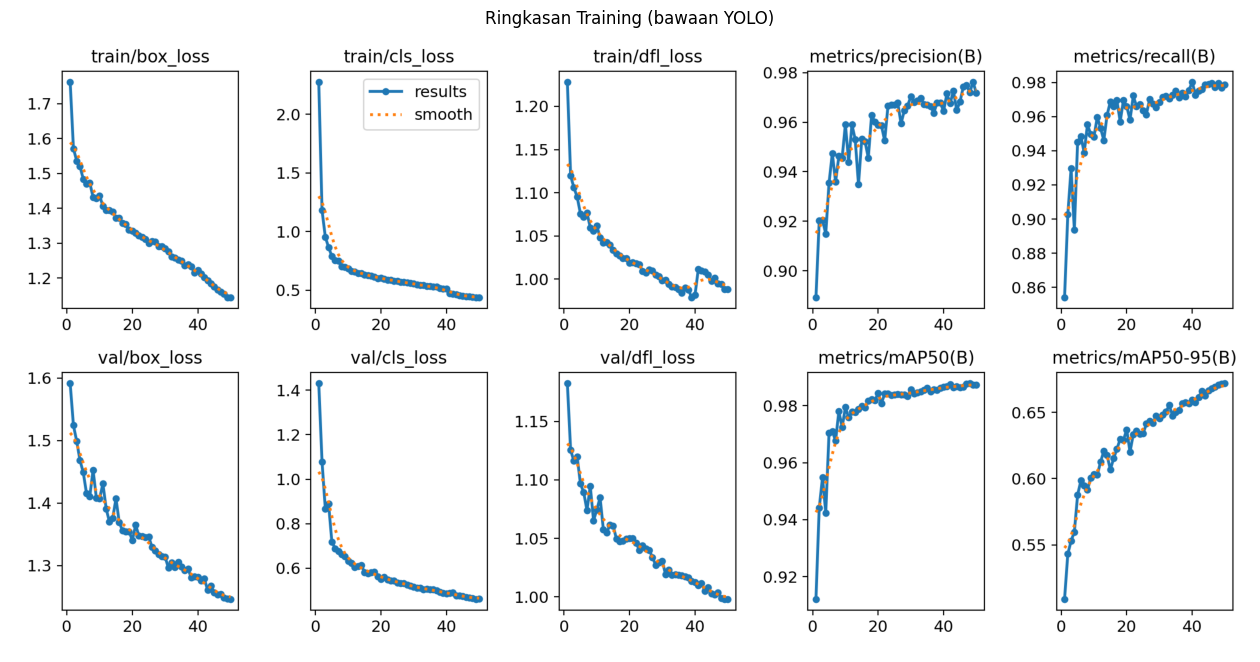

In [30]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(f"{results_dir}/results.png")
plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis('off')
plt.title("Ringkasan Training (bawaan YOLO)")
plt.show()

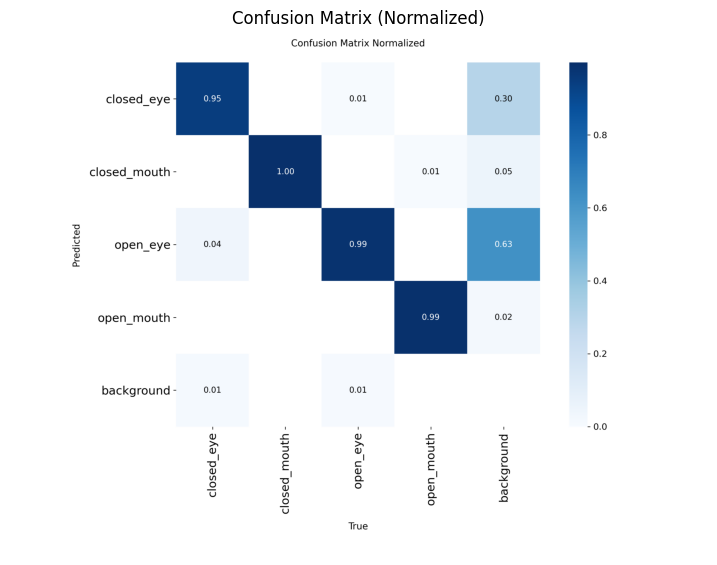

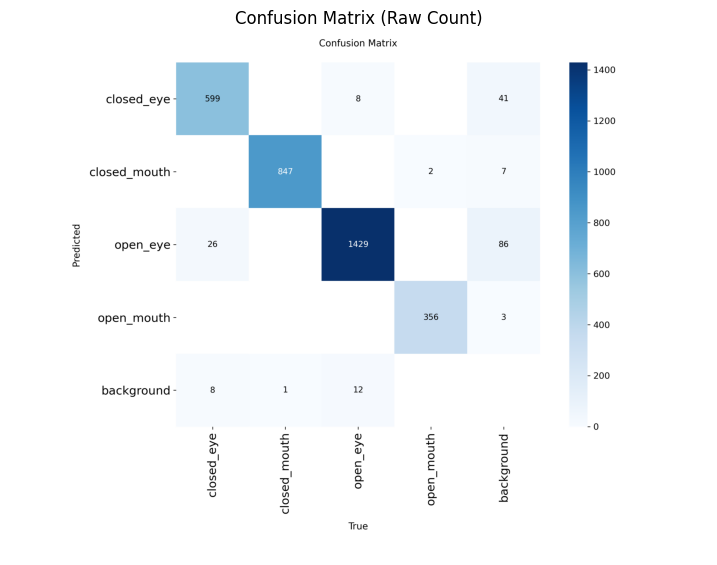

In [31]:
img_cm = Image.open(f"{results_dir}/confusion_matrix_normalized.png")
plt.figure(figsize=(9, 8))
plt.imshow(img_cm)
plt.axis('off')
plt.title("Confusion Matrix (Normalized)")
plt.show()

img_cm_raw = Image.open(f"{results_dir}/confusion_matrix.png")
plt.figure(figsize=(9, 8))
plt.imshow(img_cm_raw)
plt.axis('off')
plt.title("Confusion Matrix (Raw Count)")
plt.show()

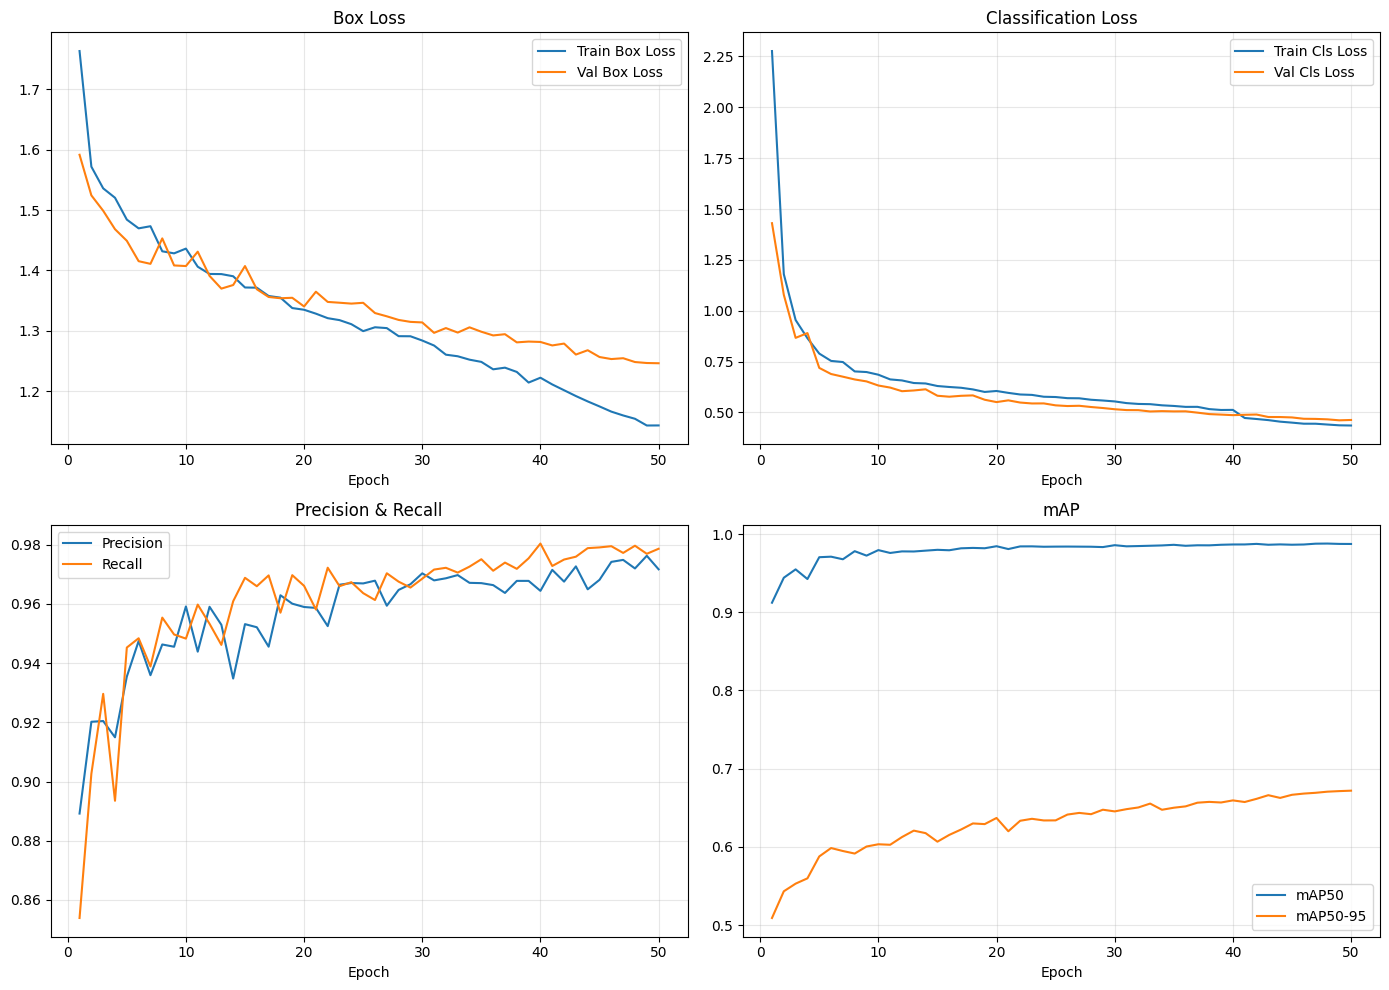

In [33]:
import pandas as pd

df = pd.read_csv(f"{results_dir}/results.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
axes[0, 0].set_title('Box Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss')
axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss')
axes[0, 1].set_title('Classification Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
axes[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
axes[1, 0].set_title('Precision & Recall')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
axes[1, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
axes[1, 1].set_title('mAP')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_dir}/custom_metrics_plot.png", dpi=150)
plt.show()

In [35]:
last_n = 5

train_loss_final = (df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']).tail(last_n).mean()
val_loss_final = (df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']).tail(last_n).mean()

gap = val_loss_final - train_loss_final
gap_ratio = gap / train_loss_final

val_loss_series = (df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss'])
min_val_loss_epoch = val_loss_series.idxmin()
total_epochs = len(df)

print(f"Train loss (avg {last_n} epoch terakhir): {train_loss_final:.4f}")
print(f"Val loss   (avg {last_n} epoch terakhir): {val_loss_final:.4f}")
print(f"Selisih (val - train): {gap:.4f}  ({gap_ratio*100:.1f}%)")
print(f"Val loss terendah di epoch: {int(df['epoch'].iloc[min_val_loss_epoch])} dari total {total_epochs} epoch")
print(f"mAP50 epoch terakhir: {df['metrics/mAP50(B)'].iloc[-1]:.3f}")
print(f"mAP50-95 epoch terakhir: {df['metrics/mAP50-95(B)'].iloc[-1]:.3f}")

print("\n=== KESIMPULAN ===")
if gap_ratio > 0.25 and min_val_loss_epoch < total_epochs - 10:
    print("Indikasi OVERFITTING")
    print(" - Val loss jauh lebih tinggi dari train loss")
    print(" - Val loss sempat naik lagi setelah titik terendah")
    print(" Saran: kurangi epoch (early stopping), tambah augmentasi, atau tambah data")
elif train_loss_final > 1.0 and df['metrics/mAP50(B)'].iloc[-1] < 0.7:
    print("Indikasi UNDERFITTING")
    print(" - Train loss masih tinggi, mAP masih rendah")
    print(" Saran: tambah epoch, gunakan model lebih besar (yolo11s/m), atau cek kualitas data")
else:
    print("Training terlihat NORMAL")
    print(" - Gap antara train dan val loss wajar")
    print(" - mAP dan loss menunjukkan model belajar dengan baik")

Train loss (avg 5 epoch terakhir): 2.5875
Val loss   (avg 5 epoch terakhir): 2.7156
Selisih (val - train): 0.1281  (5.0%)
Val loss terendah di epoch: 49 dari total 50 epoch
mAP50 epoch terakhir: 0.987
mAP50-95 epoch terakhir: 0.672

=== KESIMPULAN ===
Training terlihat NORMAL
 - Gap antara train dan val loss wajar
 - mAP dan loss menunjukkan model belajar dengan baik


Saving Screenshot 2026-07-03 120210.png to Screenshot 2026-07-03 120210.png

image 1/1 /content/Screenshot 2026-07-03 120210.png: 640x640 2 closed_eyes, 1 closed_mouth, 16.3ms
Speed: 3.4ms preprocess, 16.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-3


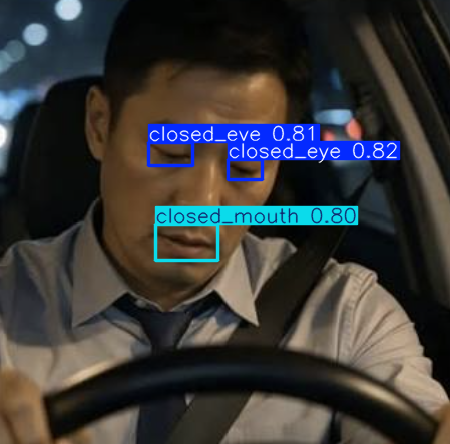

In [25]:
from google.colab import files
from ultralytics import YOLO

# Load model hasil training
model = YOLO("/content/runs/detect/fatigue_detection/yolo11n_v1/weights/best.pt")

# Upload gambar dari komputer kamu
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Prediksi
results = model.predict(source=image_path, conf=0.5, save=True)

# Tampilkan hasil langsung di notebook
results[0].show()

Saving Screenshot 2026-07-03 120301.png to Screenshot 2026-07-03 120301.png

image 1/1 /content/Screenshot 2026-07-03 120301.png: 544x640 2 closed_eyes, 1 open_mouth, 91.7ms
Speed: 2.8ms preprocess, 91.7ms inference, 1.6ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/detect/predict-4


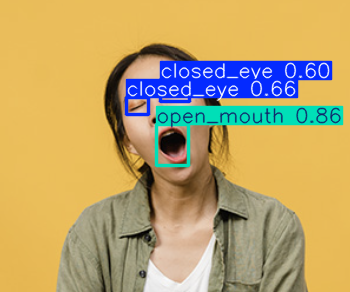

In [26]:
from google.colab import files
from ultralytics import YOLO

# Load model hasil training
model = YOLO("/content/runs/detect/fatigue_detection/yolo11n_v1/weights/best.pt")

# Upload gambar dari komputer kamu
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Prediksi
results = model.predict(source=image_path, conf=0.5, save=True)

# Tampilkan hasil langsung di notebook
results[0].show()

In [28]:
from google.colab import files

files.download('/content/runs/detect/fatigue_detection/yolo11n_v1/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>